In [16]:
from langgraph.graph import StateGraph,START,END
from langchain_core.prompts import PromptTemplate
from langchain_google_genai import ChatGoogleGenerativeAI 
from langchain_core.messages import BaseMessage, HumanMessage
from dotenv import load_dotenv
from typing import TypedDict , Literal , Annotated
from langgraph.graph.message import add_messages

from langgraph.prebuilt import ToolNode , tools_condition
from langchain_community.tools import DuckDuckGoSearchRun # type: ignore
from langchain_core.tools import tool
import requests
import random
load_dotenv()

True

In [17]:
llm = ChatGoogleGenerativeAI(model='gemini-2.5-flash')

In [ ]:
search_tool = DuckDuckGoSearchRun(region = 'us-en')

@tool
def calculate(first_num : float ,second_num : float , operation : str) -> dict:
    """
    Performs a mathematical operation on two numbers.
    operation : add , sub , mul , div
    """
    try:
        if operation == "add":
            return {"result": first_num + second_num}
        elif operation == "sub":
            return {"result": first_num - second_num}
        elif operation == "mul":
            return {"result": first_num * second_num}
        elif operation == "div":
            if second_num != 0:
                return {"result": first_num / second_num}
            else:
                return {"error": "Division by zero is not allowed"}
        else:
            return {"error": "Invalid operation. Please use add, sub, mul, or div."}
        return{'first_num':first_num,'second_num':second_num,'operation':operation,'result':result}
    except Exception as e:
        return {"error": str(e)}
    
    

In [19]:
tools = [search_tool,calculate]
llm_with_tools = llm.bind_tools(tools)

In [20]:
class chatState(TypedDict):
    messages : Annotated[list[BaseMessage], add_messages]

In [21]:
def chat_model(state:chatState):
    messages = state['messages']
    response = llm_with_tools.invoke(messages)
    return {'messages': response}

tool_node = ToolNode(tools)

In [25]:
graph = StateGraph(chatState)
graph.add_node("chat_node",chat_model)
graph.add_node("tools",tool_node)
graph.add_edge(START,"chat_node")
graph.add_conditional_edges("chat_node",tools_condition)
graph.add_edge("tools","chat_node")
workflow = graph.compile()


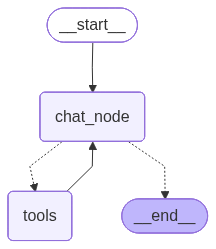

In [26]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

In [27]:
output = workflow.invoke({"messages" : [HumanMessage(content="calcaulate the sum of 45.67 and 89.23") ]})
print(output['messages'][-1].content)

The sum of 45.67 and 89.23 is 134.9.


In [28]:
output = workflow.invoke({"messages" : [HumanMessage(content="what is the capital of France?")]})
print(output['messages'][-1].content)

c:\Users\dell\Desktop\Langgraph-learning\agent\lib\site-packages\langchain_community\utilities\duckduckgo_search.py:63: RuntimeWarning: This package (`duckduckgo_search`) has been renamed to `ddgs`! Use `pip install ddgs` instead.
  with DDGS() as ddgs:
c:\Users\dell\Desktop\Langgraph-learning\agent\lib\site-packages\langchain_community\utilities\duckduckgo_search.py:64: UserWarning: backend='api' is deprecated, using backend='auto'
  ddgs_gen = ddgs.text(


The capital of France is Paris.
